# 02 — Feature Engineering

**Dataset:** Inside Airbnb — New York City (open data)  
**Goal:** Build a flat feature matrix per listing ready for modelling.

We engineer features from four sources:
1. **Calendar behaviour** (Q3+Q4 2025) — blocking rates, weekend patterns, status transitions, monthly trends, recency.
2. **Property metadata** (December 2025 snapshot) — pricing, ratings, amenities, host tenure, availability, geography.
3. **Review velocity** (December 2025 reviews) — review counts over 30 / 90 / 180 / 365-day windows.
4. **Target** (derived from December 2025 calendar) — `blocked_days_Q1_2026`.

**Key differences from old Kaggle pipeline:**
- `available ∈ {t, f}` replaces `Status ∈ {A, B, R}` — no B/R distinction.
- December 2025 price is 100% empty → use **November 2025** price (backfill with `rev/occ`).
- No pre-defined train/test split → **80/20 random split** on labeled data.
- Richer metadata: 85 cols vs 33 cols in old `property_info.csv`.

**Outputs:**
- `outputs/train_local.parquet` — 80% for model training + CV
- `outputs/test_local.parquet` — 20% for final evaluation
- `outputs/all_features.parquet` — full labeled dataset (for ensemble notebooks)

---
### Outline
1. Setup
2. Paths & Config
3. Calendar Features (Q3+Q4 2025)
4. Property Metadata (December 2025)
5. Review Velocity
6. Derive Target
7. Merge All Features
8. Feature Summary & Correlations
9. Train / Test Split & Save

## 1. Setup

In [53]:
import ast
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.4.6 | Pandas: 3.0.3


## 2. Paths & Config

In [54]:
BASE_DIR = Path('../AirBnb_Inside')
Q3_DIR   = BASE_DIR / '2025_Inside_Airbnb/Q3'
Q4_DIR   = BASE_DIR / '2025_Inside_Airbnb/Q4'
DEC_DIR  = Q4_DIR / 'December2025'
NOV_DIR  = Q4_DIR / 'November2025'
OUT_DIR  = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True, parents=True)

# Each tuple: (label, calendar_path, start_date, end_date)
# We filter each month's scrape to its own date range to build a
# continuous 6-month H2 2025 availability record.
MONTH_CONFIGS = [
    ('Jul', Q3_DIR / 'July2025'      / 'calendar.csv', '2025-07-01', '2025-07-31'),
    ('Aug', Q3_DIR / 'August2025'    / 'calendar.csv', '2025-08-02', '2025-08-31'),
    ('Sep', Q3_DIR / 'September2025' / 'calendar.csv', '2025-09-02', '2025-09-30'),
    ('Oct', Q4_DIR / 'October2025'   / 'calendar.csv', '2025-10-01', '2025-10-31'),
    ('Nov', Q4_DIR / 'November2025'  / 'calendar.csv', '2025-11-02', '2025-11-30'),
    ('Dec', Q4_DIR / 'December2025'  / 'calendar.csv', '2025-12-04', '2025-12-31'),
]

print('Data root:', BASE_DIR.resolve())
print('Output  :', OUT_DIR.resolve())

Data root: /Users/bashkal/Desktop/ML/ML-Final/Internship/AirBnb_Inside
Output  : /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs


In [55]:
def detailed_listings_path(month_dir):
    """Return path of the detailed (79+ col) listings file for a month directory."""
    for fname in ['listings.csv', 'listings-2.csv']:
        p = Path(month_dir) / fname
        with open(p) as f:
            ncols = len(f.readline().split(','))
        if ncols > 30:
            return p
    raise FileNotFoundError(f'No detailed listings file in {month_dir}')

## 3. Calendar Features (Q3+Q4 2025)

We load each monthly scrape filtered to its own calendar month, then concatenate into one
H2 2025 DataFrame. From this we compute Q3, Q4, H2-combined, and monthly-breakdown aggregates.

Minor gaps: August scrape starts Aug 2 (miss Aug 1); December starts Dec 4 (miss Dec 1–3).

In [56]:
def load_calendar_month(cal_path, start, end):
    df = pd.read_csv(
        cal_path,
        usecols=['listing_id', 'date', 'available'],
        dtype={'listing_id': 'int64', 'available': 'category'},
    )
    df['date'] = pd.to_datetime(df['date'])
    return df[(df['date'] >= start) & (df['date'] <= end)].copy()

print(f'{"Month":<5} {"Rows":>10} {"Listings":>10} {"Block rate":>12}')
print('-' * 42)
parts = []
for label, cal_path, start, end in MONTH_CONFIGS:
    m_df = load_calendar_month(cal_path, start, end)
    m_df['month_num'] = pd.to_datetime(start).month
    parts.append(m_df)
    br = (m_df['available'] == 'f').mean()
    print(f'{label:<5} {len(m_df):>10,} {m_df["listing_id"].nunique():>10,} {br:>12.3f}')

h2_cal = pd.concat(parts, ignore_index=True)
del parts
print(f'\nH2 combined: {len(h2_cal):,} rows | {h2_cal["listing_id"].nunique():,} unique listings')

Month       Rows   Listings   Block rate
------------------------------------------
Jul    1,093,964     36,345        0.702
Aug    1,080,922     36,403        0.660
Sep    1,047,224     36,178        0.708
Oct    1,085,967     36,111        0.709
Nov    1,045,723     36,353        0.670
Dec      982,765     36,261        0.649

H2 combined: 6,336,565 rows | 40,479 unique listings


In [57]:
def agg_calendar(cal_df, prefix):
    """Per-listing calendar feature aggregation for a given time window."""
    cal = cal_df[['listing_id', 'date', 'available']].copy()
    cal['is_blocked'] = (cal['available'] == 'f').astype('int8')
    cal['is_avail']   = (cal['available'] == 't').astype('int8')
    cal['is_weekend'] = cal['date'].dt.dayofweek.isin([4, 5]).astype('int8')  # Fri + Sat

    # Core blocking stats
    core = cal.groupby('listing_id').agg(
        days_total   = ('is_blocked', 'count'),
        days_blocked = ('is_blocked', 'sum'),
        days_avail   = ('is_avail',   'sum'),
    )
    core['blocking_rate'] = core['days_blocked'] / core['days_total']
    core['avail_rate']    = core['days_avail']   / core['days_total']

    # Weekend vs weekday blocking
    we = cal[cal['is_weekend'] == 1].groupby('listing_id')['is_blocked'].agg(
        we_days='count', we_blocked='sum')
    wd = cal[cal['is_weekend'] == 0].groupby('listing_id')['is_blocked'].agg(
        wd_days='count', wd_blocked='sum')
    we['we_blocking_rate'] = we['we_blocked'] / we['we_days'].replace(0, np.nan)
    wd['wd_blocking_rate'] = wd['wd_blocked'] / wd['wd_days'].replace(0, np.nan)

    # Status transitions (available→blocked = new booking proxy)
    cal_s = cal.sort_values(['listing_id', 'date'])
    cal_s['prev_avail']     = cal_s.groupby('listing_id')['is_avail'].shift(1)
    cal_s['new_blocking']   = ((cal_s['is_avail'] == 0) & (cal_s['prev_avail'] == 1)).astype('int8')
    cal_s['new_unblocking'] = ((cal_s['is_avail'] == 1) & (cal_s['prev_avail'] == 0)).astype('int8')
    trans = cal_s.groupby('listing_id').agg(
        new_blockings   = ('new_blocking',   'sum'),
        new_unblockings = ('new_unblocking', 'sum'),
    )

    result = (core
              .join(we[['we_blocking_rate', 'we_days']])
              .join(wd[['wd_blocking_rate', 'wd_days']])
              .join(trans))
    result['we_minus_wd_blocking'] = result['we_blocking_rate'] - result['wd_blocking_rate']

    result.columns = [f'{prefix}_{c}' for c in result.columns]
    result.index.name = 'listing_id'
    return result.reset_index()

In [58]:
q3_mask = h2_cal['date'] < '2025-10-01'
q4_mask = h2_cal['date'] >= '2025-10-01'

print('Computing Q3 2025 aggregates (Jul–Sep)...')
agg_q3 = agg_calendar(h2_cal[q3_mask], 'q3')
print(f'  Shape: {agg_q3.shape}')

print('Computing Q4 2025 aggregates (Oct–Dec)...')
agg_q4 = agg_calendar(h2_cal[q4_mask], 'q4')
print(f'  Shape: {agg_q4.shape}')

print('Computing H2 2025 combined aggregates...')
agg_h2 = agg_calendar(h2_cal, 'h2')
print(f'  Shape: {agg_h2.shape}')

print('\nSample Q3 aggregates:')
print(agg_q3.head(3).to_string(index=False))

Computing Q3 2025 aggregates (Jul–Sep)...
  Shape: (38203, 13)
Computing Q4 2025 aggregates (Oct–Dec)...
  Shape: (38077, 13)
Computing H2 2025 combined aggregates...
  Shape: (40479, 13)

Sample Q3 aggregates:
 listing_id  q3_days_total  q3_days_blocked  q3_days_avail  q3_blocking_rate  q3_avail_rate  q3_we_blocking_rate  q3_we_days  q3_wd_blocking_rate  q3_wd_days  q3_new_blockings  q3_new_unblockings  q3_we_minus_wd_blocking
       2539             88               32             56          0.363636       0.636364                0.375          24             0.359375          64                 1                   1                 0.015625
       2595             89               59             30          0.662921       0.337079                0.640          25             0.671875          64                 1                   1                -0.031875
       5136             30               16             14          0.533333       0.466667                0.500           8  

In [59]:
# Monthly blocking rates M7–M12 (one row per listing per month)
print('Computing monthly blocking rates M7–M12...')
monthly_frames = []
for month_num in range(7, 13):
    mdata = h2_cal[h2_cal['month_num'] == month_num].copy()
    if len(mdata) == 0:
        print(f'  M{month_num}: no data (minor scrape gap)')
        continue
    m_agg = (
        mdata.assign(is_blocked=(mdata['available'] == 'f').astype('int8'))
        .groupby('listing_id')
        .agg(**{
            f'm{month_num}_blocking_rate': ('is_blocked', 'mean'),
            f'm{month_num}_days':          ('is_blocked', 'count'),
        })
    )
    monthly_frames.append(m_agg)
    print(f'  M{month_num}: {len(m_agg):,} listings | mean_br={m_agg[f"m{month_num}_blocking_rate"].mean():.3f}')

agg_monthly = monthly_frames[0]
for mf in monthly_frames[1:]:
    agg_monthly = agg_monthly.join(mf, how='outer')
agg_monthly = agg_monthly.reset_index()
print(f'\nMonthly feature table: {agg_monthly.shape}')

Computing monthly blocking rates M7–M12...
  M7: 36,345 listings | mean_br=0.703
  M8: 36,403 listings | mean_br=0.660
  M9: 36,178 listings | mean_br=0.708
  M10: 36,111 listings | mean_br=0.710
  M11: 36,353 listings | mean_br=0.672
  M12: 36,261 listings | mean_br=0.650

Monthly feature table: (40479, 13)


In [60]:
# Recency window: December 4–31 (most recent ~28 days of training period)
recent_mask = h2_cal['date'] >= '2025-12-04'
print('Computing recency window (Dec 4–31 2025)...')
agg_recent = agg_calendar(h2_cal[recent_mask], 'recent')
print(f'Shape: {agg_recent.shape}')

# Free memory — done with raw calendar
del h2_cal
print('h2_cal freed from memory.')

Computing recency window (Dec 4–31 2025)...
Shape: (36261, 13)
h2_cal freed from memory.


## 4. Property Metadata (December 2025)

Primary source: December 2025 `listings.csv` (85 cols).  
Price source: November 2025 (Dec price is 100% empty — scrape issue).  
Fallback for empty price: `estimated_revenue_l365d / estimated_occupancy_l365d`.

In [61]:
dec_file = detailed_listings_path(DEC_DIR)
print(f'Loading December 2025 listings: {dec_file.name}')
meta = pd.read_csv(dec_file, low_memory=False)
meta['id'] = meta['id'].astype(str)
print(f'Shape: {meta.shape}')

Loading December 2025 listings: listings.csv
Shape: (36261, 85)


In [62]:
# Load November 2025 price (most recent month with valid price data)
nov_file = detailed_listings_path(NOV_DIR)
print(f'Loading price from November 2025: {nov_file.name}')
nov_price = pd.read_csv(
    nov_file,
    usecols=['id', 'price', 'estimated_revenue_l365d', 'estimated_occupancy_l365d'],
    dtype=str, low_memory=False,
)
nov_price['id'] = nov_price['id'].astype(str)

def parse_price_str(s):
    if pd.isna(s) or str(s).strip() in ('', 'nan'): return np.nan
    return float(str(s).replace('$', '').replace(',', '').strip())

nov_price['price_raw']    = nov_price['price'].apply(parse_price_str)
nov_price['est_rev']      = pd.to_numeric(nov_price['estimated_revenue_l365d'],  errors='coerce')
nov_price['est_occ']      = pd.to_numeric(nov_price['estimated_occupancy_l365d'], errors='coerce')
nov_price['price_implied'] = np.where(
    nov_price['est_occ'] > 0,
    nov_price['est_rev'] / nov_price['est_occ'],
    np.nan,
)
nov_price['price_numeric'] = nov_price['price_raw'].fillna(nov_price['price_implied'])

print(f'  Direct price coverage : {nov_price["price_raw"].notna().mean():.1%}')
print(f'  Implied price coverage: {nov_price["price_implied"].notna().mean():.1%}')
print(f'  Final coverage        : {nov_price["price_numeric"].notna().mean():.1%}')

meta = meta.merge(nov_price[['id', 'price_numeric']], on='id', how='left')

Loading price from November 2025: listings.csv
  Direct price coverage : 58.9%
  Implied price coverage: 26.7%
  Final coverage        : 58.9%


In [63]:
# Parse percentage strings: "100%" or "N/A" → float
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in meta.columns:
        meta[f'{col}_num'] = (
            meta[col].astype(str)
            .str.replace('%', '', regex=False)
            .replace({'N/A': np.nan, 'nan': np.nan, '': np.nan})
            .astype(float)
        )

# Boolean t/f flags → 0/1
bool_map = {'t': 1.0, 'f': 0.0}
for col in ['host_is_superhost', 'instant_bookable', 'host_identity_verified', 'host_has_profile_pic']:
    if col in meta.columns:
        meta[f'{col}_enc'] = meta[col].map(bool_map).astype('float32')

# Cast numeric columns
# NOTE: availability_30/60/90/365 are excluded — they are Airbnb's forward-looking
# calendar counts (next X days from the Dec 2025 scrape date), which directly overlap
# with the Q1 2026 prediction window and constitute data leakage.
NUMERIC_COLS = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'maximum_nights',
    'minimum_minimum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'number_of_reviews_ly', 'reviews_per_month',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'calculated_host_listings_count',
    'hosts_time_as_host_years', 'hosts_time_as_host_months',
    'hosts_time_as_user_years', 'hosts_time_as_user_months',
]
for col in NUMERIC_COLS:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors='coerce').astype('float32')

print('Numeric parsing done.')
print(f'  price_numeric: {meta["price_numeric"].notna().mean():.1%} coverage')

Numeric parsing done.
  price_numeric: 56.2% coverage


In [64]:
REF_DATE = pd.Timestamp('2026-01-01')  # start of prediction window

for col in ['host_since', 'first_review', 'last_review']:
    if col in meta.columns:
        meta[col] = pd.to_datetime(meta[col], errors='coerce')

if 'host_since'   in meta.columns: meta['host_age_days']          = (REF_DATE - meta['host_since']).dt.days.astype('float32')
if 'first_review' in meta.columns: meta['listing_age_days']       = (REF_DATE - meta['first_review']).dt.days.astype('float32')
if 'last_review'  in meta.columns: meta['days_since_last_review'] = (REF_DATE - meta['last_review']).dt.days.astype('float32')

# Derived numeric features
meta['has_reviews']    = (meta.get('number_of_reviews', pd.Series(0)) > 0).astype('int8')
if 'price_numeric' in meta.columns and 'accommodates' in meta.columns:
    meta['price_per_guest'] = (meta['price_numeric'] / meta['accommodates'].replace(0, np.nan)).astype('float32')
if 'price_numeric' in meta.columns and 'minimum_nights' in meta.columns:
    meta['min_stay_x_price'] = (meta['minimum_nights'] * meta['price_numeric']).astype('float32')
if 'estimated_revenue_l365d' in meta.columns and 'estimated_occupancy_l365d' in meta.columns:
    meta['implied_nightly_rate'] = (meta['estimated_revenue_l365d'] /
                                    meta['estimated_occupancy_l365d'].replace(0, np.nan)).astype('float32')

print('Date / derived features added.')
for c in ['host_age_days', 'listing_age_days', 'days_since_last_review']:
    if c in meta.columns:
        print(f'  {c}: {meta[c].notna().mean():.1%} coverage, median={meta[c].median():.0f} days')

Date / derived features added.
  host_age_days: 100.0% coverage, median=3429 days
  listing_age_days: 68.7% coverage, median=1687 days
  days_since_last_review: 68.7% coverage, median=600 days


In [65]:
def parse_bathrooms(s):
    if pd.isna(s) or str(s).strip() == '': return np.nan, np.nan
    s = str(s).lower().strip()
    is_shared = 1.0 if 'shared' in s else 0.0
    m = re.search(r'(\d+\.?\d*)', s)
    num = float(m.group(1)) if m else np.nan
    if 'half' in s and (pd.isna(num) or num == 0): num = 0.5
    return num, is_shared

if 'bathrooms_text' in meta.columns:
    parsed = meta['bathrooms_text'].apply(parse_bathrooms)
    meta['bathrooms_num']  = parsed.apply(lambda x: x[0]).astype('float32')
    meta['bath_is_shared'] = parsed.apply(lambda x: x[1]).astype('float32')

    # Use bathrooms_num as primary; fall back to bathrooms (raw) if available
    if 'bathrooms' in meta.columns:
        meta['bathrooms_num'] = meta['bathrooms_num'].fillna(meta['bathrooms'])

    print(f'bathrooms_num  : {meta["bathrooms_num"].notna().mean():.1%} coverage')
    print(f'bath_is_shared : {meta["bath_is_shared"].value_counts().to_dict()}')

bathrooms_num  : 99.9% coverage
bath_is_shared : {0.0: 26669, 1.0: 9484}


In [66]:
KEY_AMENITIES = {
    'wifi':         ['wifi', 'fast wifi'],
    'kitchen':      ['kitchen', 'kitchenette'],
    'ac':           ['air conditioning', 'central air conditioning'],
    'washer':       ['washer'],
    'dryer':        ['dryer'],
    'parking':      ['free parking', 'paid parking', 'free street parking', 'free driveway parking'],
    'elevator':     ['elevator'],
    'tv':           ['tv', 'hdtv'],
    'pool':         ['pool'],
    'gym':          ['gym', 'exercise equipment', 'fitness room'],
    'co_alarm':     ['carbon monoxide alarm'],
    'long_term':    ['long term stays allowed'],
    'self_checkin': ['self check-in', 'lockbox', 'smart lock', 'keypad'],
    'hot_tub':      ['hot tub', 'private hot tub'],
}

if 'amenities' in meta.columns:
    amen_str = meta['amenities'].fillna('').astype(str).str.lower()
    for flag, keywords in KEY_AMENITIES.items():
        meta[f'amen_{flag}'] = amen_str.apply(
            lambda s: int(any(kw in s for kw in keywords))
        ).astype('int8')

    print('Amenity flags coverage:')
    for flag in KEY_AMENITIES:
        print(f'  amen_{flag}: {meta[f"amen_{flag}"].mean():.1%}')

Amenity flags coverage:
  amen_wifi: 97.9%
  amen_kitchen: 88.4%
  amen_ac: 76.4%
  amen_washer: 50.6%
  amen_dryer: 73.3%
  amen_parking: 46.2%
  amen_elevator: 24.7%
  amen_tv: 78.3%
  amen_pool: 3.2%
  amen_gym: 18.0%
  amen_co_alarm: 78.7%
  amen_long_term: 35.5%
  amen_self_checkin: 40.0%
  amen_hot_tub: 4.8%


In [67]:
def map_property_type(s):
    if pd.isna(s): return 'Other'
    s = str(s).lower()
    if 'hotel' in s or 'hostel' in s or 'boutique' in s: return 'Hotel_Hostel'
    if s.startswith('entire'): return 'Entire_Place'
    if 'private room' in s: return 'Private_Room'
    if 'shared room' in s: return 'Shared_Room'
    return 'Other'

if 'property_type' in meta.columns:
    meta['property_type_grp'] = meta['property_type'].apply(map_property_type)

# One-hot encode grouped property type, room type, and borough
for col in ['property_type_grp', 'room_type', 'neighbourhood_group_cleansed']:
    if col in meta.columns:
        dummies = pd.get_dummies(meta[col], prefix=col, drop_first=True, dtype='int8')
        meta = pd.concat([meta, dummies], axis=1)
        print(f'{col}: {dummies.shape[1]} dummy columns added | categories: {meta[col].unique().tolist()}')

# Neighbourhood frequency encoding (avoids target leakage)
if 'neighbourhood_cleansed' in meta.columns:
    nb_freq = meta['neighbourhood_cleansed'].value_counts()
    meta['neighbourhood_freq'] = meta['neighbourhood_cleansed'].map(nb_freq).astype('float32')
    print(f'neighbourhood_freq: {meta["neighbourhood_freq"].describe().round(0).to_dict()}')

property_type_grp: 4 dummy columns added | categories: ['Private_Room', 'Entire_Place', 'Hotel_Hostel', 'Shared_Room', 'Other']
room_type: 3 dummy columns added | categories: ['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
neighbourhood_group_cleansed: 4 dummy columns added | categories: ['Brooklyn', 'Manhattan', 'Bronx', 'Queens', 'Staten Island']
neighbourhood_freq: {'count': 36261.0, 'mean': 973.0, 'std': 806.0, 'min': 1.0, '25%': 264.0, '50%': 636.0, '75%': 1514.0, 'max': 2613.0}


In [68]:
if 'latitude' in meta.columns and 'longitude' in meta.columns:
    coords = meta[['latitude', 'longitude']].copy()
    coords_filled = coords.fillna({'latitude': coords['latitude'].median(),
                                   'longitude': coords['longitude'].median()})
    kmeans = KMeans(n_clusters=20, random_state=RANDOM_STATE, n_init=10)
    meta['geo_cluster'] = kmeans.fit_predict(coords_filled).astype('int8')
    print(f'KMeans geo cluster: 20 clusters')
    print(f'Cluster sizes (top 5): {meta["geo_cluster"].value_counts().head(5).to_dict()}')

KMeans geo cluster: 20 clusters
Cluster sizes (top 5): {12: 4999, 7: 3342, 4: 3150, 15: 3146, 3: 2839}


## 5. Review Velocity

Each stay typically generates a review — review counts over recent windows are a strong proxy for booking activity.  
We compute 30 / 90 / 180 / 365-day review counts as of Dec 31, 2025 (end of training period).

In [69]:
print('Loading December 2025 reviews...')
reviews = pd.read_csv(
    DEC_DIR / 'reviews.csv',
    usecols=['listing_id', 'date'],
    dtype={'listing_id': 'int64'},
)
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')
reviews = reviews.dropna(subset=['date'])
print(f'Reviews: {len(reviews):,} rows | date range: {reviews["date"].min().date()} → {reviews["date"].max().date()}')

CUT_DATE = pd.Timestamp('2025-12-31')
print(f'\nReview velocity (as of {CUT_DATE.date()}):')
for days, col in [(30, 'rev_30d'), (90, 'rev_90d'), (180, 'rev_180d'), (365, 'rev_365d')]:
    start = CUT_DATE - pd.Timedelta(days=days)
    mask  = (reviews['date'] >= start) & (reviews['date'] <= CUT_DATE)
    counts = reviews[mask].groupby('listing_id').size().rename(col)
    meta[col] = (
        meta['id'].map(counts.rename(index=str))
        .fillna(0).astype('int32')
    )
    n_active = (meta[col] > 0).sum()
    print(f'  {col}: {n_active:,} listings with ≥1 review  |  median={meta[col].median():.0f}')

Loading December 2025 reviews...
Reviews: 991,640 rows | date range: 2009-05-25 → 2025-12-08

Review velocity (as of 2025-12-31):
  rev_30d: 448 listings with ≥1 review  |  median=0
  rev_90d: 5,849 listings with ≥1 review  |  median=0
  rev_180d: 8,637 listings with ≥1 review  |  median=0
  rev_365d: 10,606 listings with ≥1 review  |  median=0


## 6. Derive Target

From December 2025 calendar: count days with `available='f'` per listing in **Jan 1 – Mar 31, 2026** (90 days max).

In [70]:
print('Loading December 2025 calendar for Q1 2026 target...')
dec_cal = pd.read_csv(
    DEC_DIR / 'calendar.csv',
    usecols=['listing_id', 'date', 'available'],
    dtype={'listing_id': 'int64', 'available': 'category'},
)
dec_cal['date'] = pd.to_datetime(dec_cal['date'])
q1_cal = dec_cal[
    (dec_cal['date'] >= '2026-01-01') &
    (dec_cal['date'] <= '2026-03-31')
].copy()

target = (
    q1_cal
    .assign(is_blocked=(q1_cal['available'] == 'f').astype('int8'))
    .groupby('listing_id')
    .agg(blocked_days_Q1_2026=('is_blocked', 'sum'))
    .reset_index()
)
target['id'] = target['listing_id'].astype(str)
del dec_cal, q1_cal

y = target['blocked_days_Q1_2026']
print(f'Target listings: {len(target):,}')
print(f'  mean={y.mean():.1f}  median={y.median():.0f}  std={y.std():.1f}')
print(f'  zero rate={( y==0).mean():.3f}  fully blocked (90d)={(y==90).mean():.3f}')

Loading December 2025 calendar for Q1 2026 target...
Target listings: 36,261
  mean=44.2  median=31  std=41.1
  zero rate=0.325  fully blocked (90d)=0.392


## 7. Merge All Features

In [71]:
# Convert listing_id to string id in all calendar aggregates for consistent join key
for df in [agg_q3, agg_q4, agg_h2, agg_monthly, agg_recent]:
    df['id'] = df['listing_id'].astype(str)

# Start from target
feat = target[['id', 'blocked_days_Q1_2026']].copy()
print(f'Start: {feat.shape}')

# Merge calendar features
for agg_df, name in [
    (agg_q3,     'Q3 calendar'),
    (agg_q4,     'Q4 calendar'),
    (agg_h2,     'H2 combined'),
    (agg_monthly,'monthly breakdown'),
    (agg_recent, 'recency window'),
]:
    merge_cols = [c for c in agg_df.columns if c not in ('listing_id', 'id')]
    feat = feat.merge(agg_df[['id'] + merge_cols], on='id', how='left')
    print(f'After {name}: {feat.shape}')

# Merge property metadata — drop raw/text columns not useful for models
DROP_META = [
    'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description',
    'neighborhood_overview', 'picture_url', 'host_url', 'host_thumbnail_url',
    'host_picture_url', 'host_about', 'host_location', 'host_name',
    'host_since', 'host_verifications', 'host_neighbourhood',
    'amenities', 'price', 'bathrooms_text', 'bathrooms',  # superseded by parsed versions
    'host_response_rate', 'host_acceptance_rate',          # superseded by _num versions
    'host_is_superhost', 'instant_bookable',
    'host_identity_verified', 'host_has_profile_pic',      # superseded by _enc versions
    'first_review', 'last_review', 'host_since',           # superseded by _days versions
    'host_profile_id', 'host_profile_url', 'host_id',
    'property_type', 'property_type_grp',                  # superseded by dummies
    'room_type', 'neighbourhood', 'neighbourhood_cleansed',
    'neighbourhood_group_cleansed',                        # superseded by dummies
    'calendar_last_scraped', 'calendar_updated',
    'has_availability', 'availability_eoy',
    'host_response_time',  # high-cardinality string
    'license',
    # Leaky forward-looking features: Airbnb's pre-computed availability counts
    # as of the Dec 2025 scrape date directly overlap the Q1 2026 target window
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
]
meta_cols = [c for c in meta.columns if c not in DROP_META]
feat = feat.merge(meta[meta_cols], on='id', how='left')
print(f'After metadata  : {feat.shape}')

Start: (36261, 2)
After Q3 calendar: (36261, 14)
After Q4 calendar: (36261, 26)
After H2 combined: (36261, 38)
After monthly breakdown: (36261, 50)
After recency window: (36261, 62)
After metadata  : (36261, 146)


In [72]:
# Cross-table derived features
if 'q3_blocking_rate' in feat.columns and 'q4_blocking_rate' in feat.columns:
    feat['q3_to_q4_blocking_trend'] = (feat['q4_blocking_rate'] - feat['q3_blocking_rate']).astype('float32')
    print('q3_to_q4_blocking_trend added (Q4 - Q3 blocking rate)')

print(f'\nFinal feature matrix: {feat.shape}')

q3_to_q4_blocking_trend added (Q4 - Q3 blocking rate)

Final feature matrix: (36261, 147)


## 8. Feature Summary & Correlations

In [73]:
# Column type inventory
n_num = feat.select_dtypes(include='number').shape[1]
n_obj = feat.select_dtypes(include='object').shape[1]
obj_remaining = feat.select_dtypes(include='object').columns.tolist()
print(f'Feature matrix: {feat.shape}')
print(f'  Numeric  : {n_num}')
print(f'  Object   : {n_obj}  → {obj_remaining}')

# Missing value report
mv = feat.isna().mean().sort_values(ascending=False)
mv_top = mv[mv > 0].head(25)
print(f'\nTop columns by missing rate ({len(mv[mv>0])} columns have NaN):')
print((mv_top * 100).round(1).astype(str).to_string())

Feature matrix: (36261, 147)
  Numeric  : 146
  Object   : 1  → ['id']

Top columns by missing rate (57 columns have NaN):
implied_nightly_rate           100.0
estimated_revenue_l365d        100.0
price_numeric                   43.8
min_stay_x_price                43.8
price_per_guest                 43.8
host_response_rate_num          41.8
beds                            41.1
host_acceptance_rate_num        40.7
review_scores_location          31.3
review_scores_value             31.3
review_scores_checkin           31.3
review_scores_accuracy          31.3
review_scores_communication     31.3
review_scores_cleanliness       31.3
reviews_per_month               31.3
review_scores_rating            31.3
listing_age_days                31.3
days_since_last_review          31.3
bedrooms                        16.6
m7_blocking_rate                 9.1
m7_days                          9.1
m8_days                          7.4
m8_blocking_rate                 7.4
m9_days                   

In [74]:
num_feat = feat.select_dtypes(include='number').copy()
corr_target = (
    num_feat.corr()['blocked_days_Q1_2026']
    .drop('blocked_days_Q1_2026', errors='ignore')
    .sort_values(key=abs, ascending=False)
)
print('Top 30 features by |Pearson r| with blocked_days_Q1_2026:')
print(corr_target.head(30).round(4).to_string())

Top 30 features by |Pearson r| with blocked_days_Q1_2026:
q4_wd_blocking_rate        0.7264
recent_wd_blocking_rate    0.7244
h2_wd_blocking_rate        0.7204
q4_days_blocked            0.7199
q4_avail_rate             -0.7194
q4_blocking_rate           0.7194
h2_days_blocked            0.7185
recent_avail_rate         -0.7154
m12_blocking_rate          0.7154
recent_blocking_rate       0.7154
h2_avail_rate             -0.7143
h2_blocking_rate           0.7143
recent_days_avail         -0.7141
q4_days_avail             -0.7085
recent_days_blocked        0.7062
q4_we_blocking_rate        0.6933
h2_we_blocking_rate        0.6905
h2_days_avail             -0.6868
recent_we_blocking_rate    0.6788
q3_days_blocked            0.6710
q3_wd_blocking_rate        0.6676
m11_blocking_rate          0.6674
q3_blocking_rate           0.6622
q3_avail_rate             -0.6622
q3_days_avail             -0.6550
q3_we_blocking_rate        0.6390
m8_blocking_rate           0.6303
m10_blocking_rate       

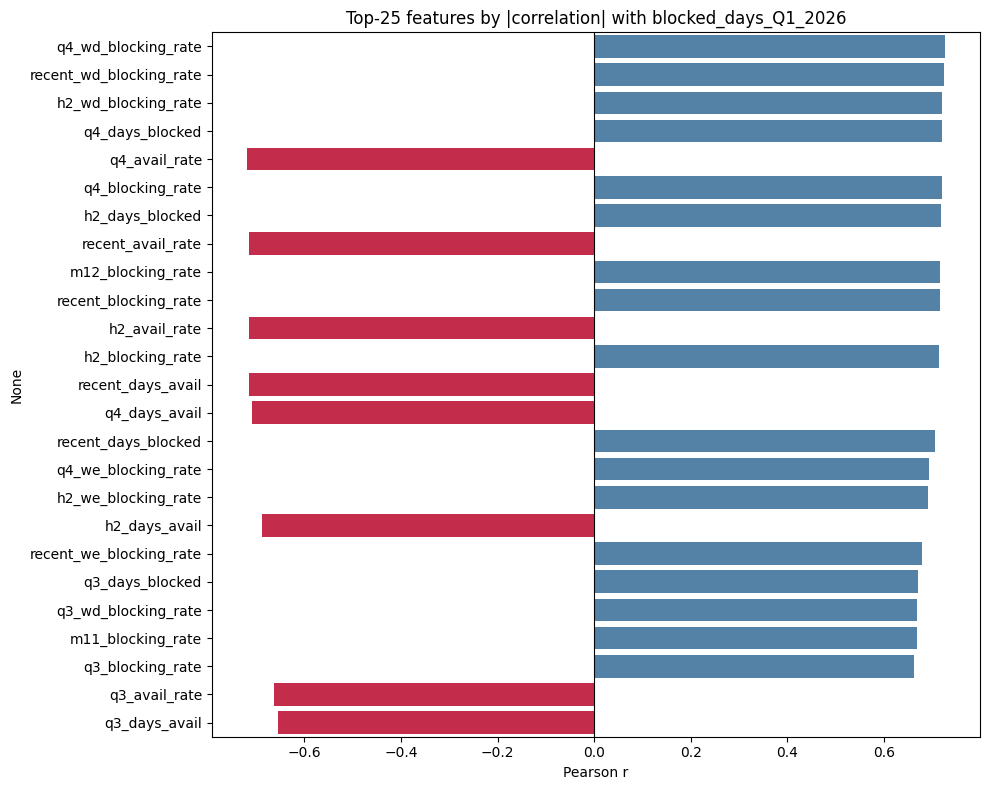

In [75]:
top25 = corr_target.head(25)
colors = ['crimson' if v < 0 else 'steelblue' for v in top25.values]

fig, ax = plt.subplots(figsize=(10, 8))
import seaborn as sns
sns.barplot(x=top25.values, y=top25.index, ax=ax, palette=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top-25 features by |correlation| with blocked_days_Q1_2026')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig(Path('../outputs') / 'fe_top_correlations.png', dpi=120)
plt.show()

In [76]:
# Print full feature inventory grouped by source
groups = {
    'Calendar Q3' :   [c for c in feat.columns if c.startswith('q3_')],
    'Calendar Q4' :   [c for c in feat.columns if c.startswith('q4_')],
    'Calendar H2' :   [c for c in feat.columns if c.startswith('h2_')],
    'Calendar Monthly': [c for c in feat.columns if c.startswith('m') and '_blocking' in c],
    'Recency'     :   [c for c in feat.columns if c.startswith('recent_')],
    'Cross-table' :   [c for c in feat.columns if 'trend' in c],
    'Reviews'     :   [c for c in feat.columns if c.startswith('rev_')],
    'Price'       :   [c for c in feat.columns if 'price' in c or 'revenue' in c or 'occupancy' in c],
    'Review scores':  [c for c in feat.columns if c.startswith('review_scores_') or c == 'reviews_per_month'],
    'Property type':  [c for c in feat.columns if 'property_type_grp' in c or 'room_type' in c],
    'Amenities'   :   [c for c in feat.columns if c.startswith('amen_')],
    'Borough'     :   [c for c in feat.columns if 'neighbourhood_group_cleansed' in c or c == 'neighbourhood_freq'],
    'Geography'   :   ['latitude', 'longitude', 'geo_cluster'],
    'Host'        :   [c for c in feat.columns if 'host_' in c],
    'Other meta'  :   [c for c in feat.columns if c in [
        'accommodates', 'bedrooms', 'beds', 'bathrooms_num', 'bath_is_shared',
        'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm',
        'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
        'has_reviews', 'price_per_guest', 'min_stay_x_price',
        'listing_age_days', 'days_since_last_review',
    ]],
}

total_feats = 0
for grp, cols in groups.items():
    present = [c for c in cols if c in feat.columns]
    total_feats += len(present)
    print(f'{grp:<20}: {len(present):3d}  {present[:5]}...' if len(present) > 5 else f'{grp:<20}: {len(present):3d}  {present}')
print(f'\nTotal counted: {total_feats} | Actual numeric: {n_num - 1}  (+1 target)')

Calendar Q3         :  13  ['q3_days_total', 'q3_days_blocked', 'q3_days_avail', 'q3_blocking_rate', 'q3_avail_rate']...
Calendar Q4         :  12  ['q4_days_total', 'q4_days_blocked', 'q4_days_avail', 'q4_blocking_rate', 'q4_avail_rate']...
Calendar H2         :  12  ['h2_days_total', 'h2_days_blocked', 'h2_days_avail', 'h2_blocking_rate', 'h2_avail_rate']...
Calendar Monthly    :   6  ['m7_blocking_rate', 'm8_blocking_rate', 'm9_blocking_rate', 'm10_blocking_rate', 'm11_blocking_rate']...
Recency             :  12  ['recent_days_total', 'recent_days_blocked', 'recent_days_avail', 'recent_blocking_rate', 'recent_avail_rate']...
Cross-table         :   1  ['q3_to_q4_blocking_trend']
Reviews             :   4  ['rev_30d', 'rev_90d', 'rev_180d', 'rev_365d']
Price               :   5  ['estimated_occupancy_l365d', 'estimated_revenue_l365d', 'price_numeric', 'price_per_guest', 'min_stay_x_price']
Review scores       :   8  ['review_scores_rating', 'review_scores_accuracy', 'review_scores_c

## 9. Train / Test Split & Save

In [77]:
# Drop remaining object columns — models need numeric input
obj_cols = feat.select_dtypes(include='object').columns.tolist()
obj_cols_drop = [c for c in obj_cols if c != 'id']  # keep id for traceability
feat_model = feat.drop(columns=obj_cols_drop)
print(f'Object columns dropped: {obj_cols_drop}')
print(f'Model-ready matrix: {feat_model.shape}')

# 80/20 random split
train_local, test_local = train_test_split(
    feat_model, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)
print(f'\nTrain (80%): {train_local.shape}')
print(f'Test  (20%): {test_local.shape}')

# Target check
print(f'\nTrain target — mean={train_local["blocked_days_Q1_2026"].mean():.2f}  '
      f'std={train_local["blocked_days_Q1_2026"].std():.2f}')
print(f'Test  target — mean={test_local["blocked_days_Q1_2026"].mean():.2f}  '
      f'std={test_local["blocked_days_Q1_2026"].std():.2f}')

Object columns dropped: []
Model-ready matrix: (36261, 147)

Train (80%): (29008, 147)
Test  (20%): (7253, 147)

Train target — mean=44.17  std=41.12
Test  target — mean=44.40  std=41.09


In [78]:
try:
    train_local.to_parquet(OUT_DIR / 'train_local.parquet',  index=False)
    test_local .to_parquet(OUT_DIR / 'test_local.parquet',   index=False)
    feat_model .to_parquet(OUT_DIR / 'all_features.parquet', index=False)
    print('Saved parquet files to', OUT_DIR.resolve())
except Exception as e:
    print('Parquet failed, saving CSV:', e)
    train_local.to_csv(OUT_DIR / 'train_local.csv',  index=False)
    test_local .to_csv(OUT_DIR / 'test_local.csv',   index=False)
    feat_model .to_csv(OUT_DIR / 'all_features.csv', index=False)

print('\nFiles saved:')
for f in OUT_DIR.glob('*.parquet'):
    print(f'  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)')

Saved parquet files to /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs

Files saved:
  all_features.parquet  (4.0 MB)
  train_local.parquet  (3.6 MB)
  test_local.parquet  (1.1 MB)


## Summary

| Feature group | # features | Source |
|---|---|---|
| Calendar Q3 2025 (Jul–Sep) | ~12 | Monthly calendar scrapes |
| Calendar Q4 2025 (Oct–Dec) | ~12 | Monthly calendar scrapes |
| Calendar H2 combined | ~12 | All 6 months |
| Monthly blocking rate M7–M12 | 12 | Per-month calendar |
| Recency window (Dec 4–31) | ~12 | December calendar |
| Cross-table derived | 1 | Q3→Q4 blocking trend |
| Review velocity | 4 | December reviews.csv |
| Price & revenue | ~5 | November listings + implied |
| Review scores | 7 | December listings |
| Property type (one-hot) | ~4 | December listings |
| Amenity flags | 14 | December listings |
| Borough (one-hot) | ~4 | December listings |
| Geography (lat, lon, cluster) | 3 | December listings + KMeans |
| Host features | ~10 | December listings |
| Other metadata | ~15 | December listings |

**~146 numeric features total** — `availability_30/60/90/365` are excluded as they are
Airbnb's forward-looking calendar counts from the December 2025 scrape date, which
directly overlap the Q1 2026 prediction window and would constitute data leakage.

### Consumed by model notebooks
All model notebooks (`03_Linear_Baseline` → `07_Blend`) load `train_local.parquet` and `test_local.parquet`.  
Target column: **`blocked_days_Q1_2026`** (0–90 days blocked in Jan–Mar 2026).